In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import mglearn 
import tensorflow as tf 

In [2]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [3]:
np.random.seed(180)
tf.random.set_seed(180)

In [4]:
people = fetch_lfw_people(
    min_faces_per_person=20,
    resize=0.7
)

print(people.data.shape)
print(people.target.shape)

image_shape = people.images[0].shape
print(image_shape)

(3023, 5655)
(3023,)
(87, 65)


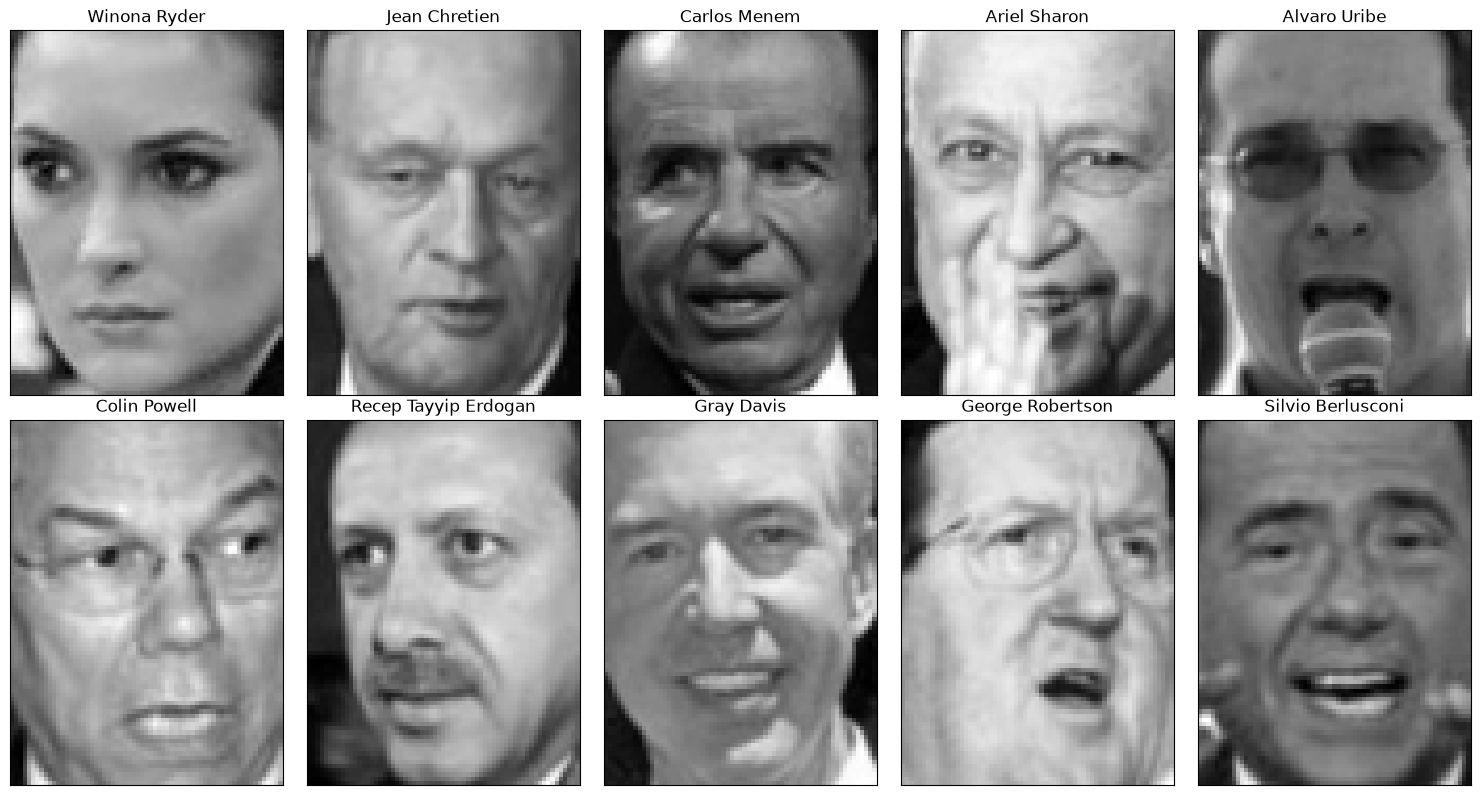

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 8),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for target, image, ax in zip(
    people.target,
    people.images,
    axes.ravel()
):
    ax.imshow(image, cmap='gray')
    ax.set_title(people.target_names[target])

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    people.data,
    people.target,
    test_size=0.2,
    random_state=20
)


y_train = y_train.astype(int)
y_test = y_test.astype(int)


batch_size = len(X_train)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("people.images.shape:", people.images.shape)

print("Number of classes:", len(people.target_names))

X_train shape: (2418, 5655)
y_train shape: (2418,)
y_test shape: (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [7]:
import numpy as np


counts = np.bincount(people.target)


for i, (count, name) in enumerate(zip(counts, people.target_names)):
    print(
        "{0:25} {1:3}".format(name, count),
        end=" "
    )

    if (i + 1) % 3 == 0:
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

mask = np.zeros(people.target.shape, dtype=np.bool_)

for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = True


X_people = people.data[mask]
y_people = people.target[mask]

X_people = X_people / 255.0


X_train, X_test, y_train, y_test = train_test_split(
    X_people,
    y_people,
    stratify=y_people,
    random_state=0
)

# KNN without PCA
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)

print(
    "Test set score of 1-NN: {:.2f}".format(
        knn.score(X_test, y_test)
    )
)

Test set score of 1-NN: 0.22


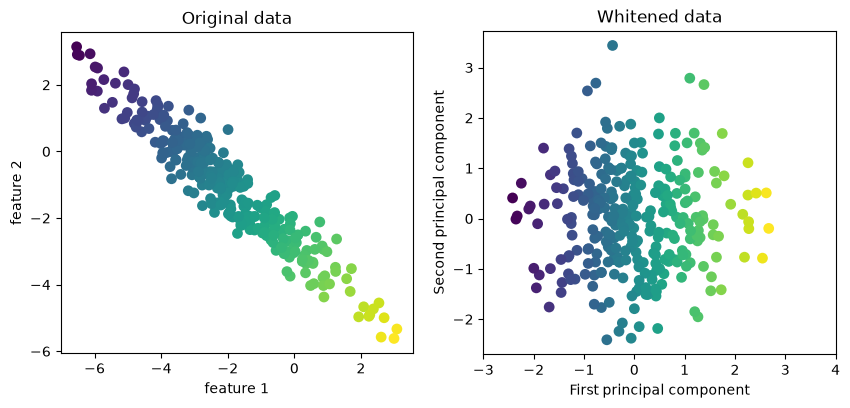

In [9]:
mglearn.plots.plot_pca_whitening() 
plt.show() 

In [10]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(
    n_components=100,
    whiten=True,
    random_state=0
).fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca.shape:", X_train_pca.shape)


knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train_pca, y_train)

print(
    "Test set accuracy: {:.2f}".format(
        knn.score(X_test_pca, y_test)
    )
)

print(
    "pca.components_.shape:",
    pca.components_.shape
)

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


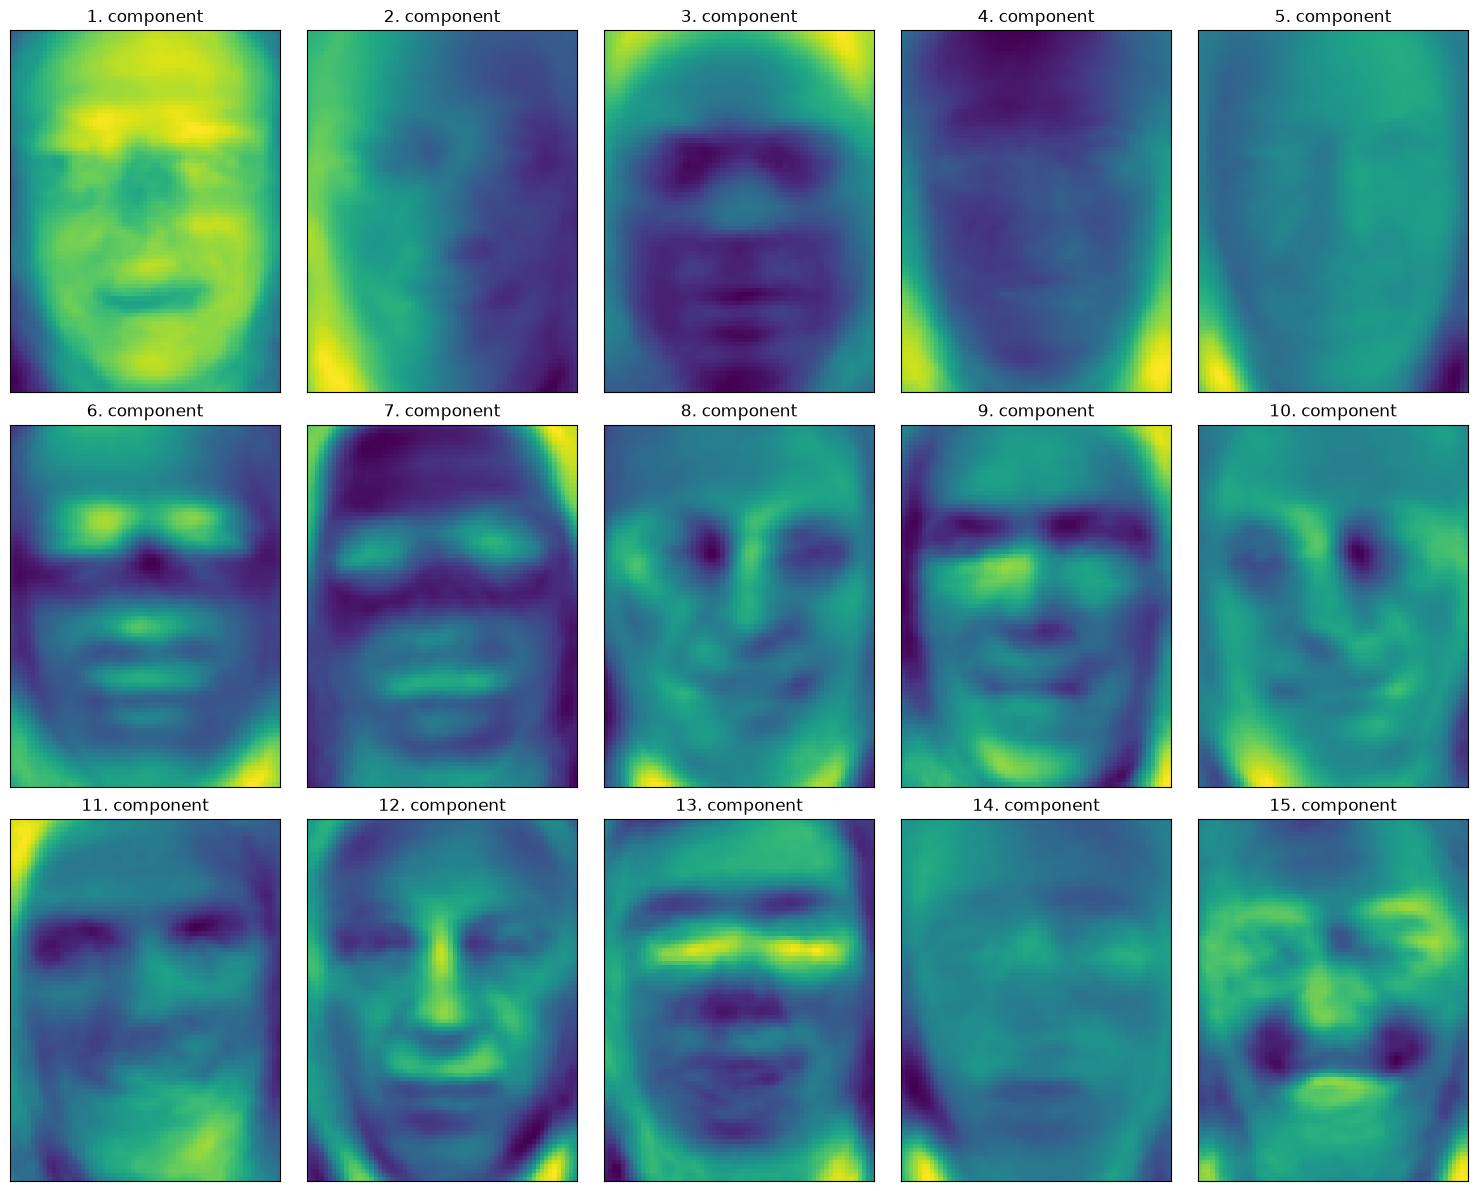

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 5,
    figsize=(15, 12),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title(f"{i + 1}. component")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1547, 100)
X_test_scaled shape: (516, 100)


In [13]:

# Build the Neural Network model
model = Sequential([
    Input(shape=(100,)),

    Dense(
        300,
        activation='relu'
    ),

    Dense(
        100,
        activation='relu'
    ),

    Dense(
        len(np.unique(y_train)),
        activation='softmax'
    )
])

# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 300)                 │          30,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 62)                  │           6,262 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,662 (260.40 KB)

 Trainable params: 66,662 (260.40 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:

history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=50,
    epochs=20,
    shuffle=False,
    verbose=1
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0213 - loss: 4.1253
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0310 - loss: 4.0849
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0530 - loss: 4.0567
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0614 - loss: 4.0270
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0743 - loss: 3.9937
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0937 - loss: 3.9565
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1157 - loss: 3.9091
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1383 - loss: 3.8517
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1648 - loss: 3.7786
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1797 - loss: 3.6895
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2107 - loss: 3.5781
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy:

In [17]:
loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3391 - loss: 2.7397
Test Loss: 2.73968243598938
Test Accuracy: 0.33914729952812195
